In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt 

In [2]:
#params

image_size = 256
batch_size = 32
channel = 3
epochs = 2

In [3]:
#creating data set 
dataset = tf.keras.utils.image_dataset_from_directory(
    "FinalDataSet",
    shuffle=True,
    image_size=(image_size,image_size),
    batch_size=batch_size
)

Found 5240 files belonging to 20 classes.


In [4]:
class_names = dataset.class_names

In [5]:
class_names 

['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa',
 'momos',
 'paani_puri',
 'pakode',
 'pav_bhaji',
 'pizza',
 'samosa']

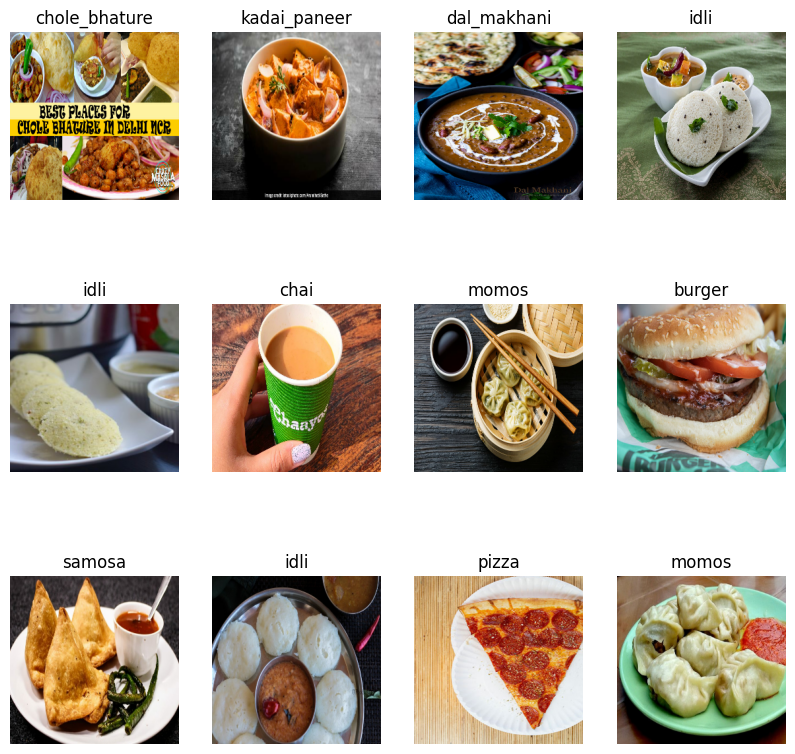

In [6]:
plt.figure(figsize = (10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1) 
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [7]:
train_size = 0.8
len(dataset) * train_size

131.20000000000002

In [8]:
train_ds = dataset.take(131)

In [9]:
bal_ds=dataset.skip(131)

In [10]:
val_size =.1


In [11]:
len(dataset) * val_size

16.400000000000002

In [12]:
val_ds = bal_ds.take(16)
test_ds = bal_ds.skip(16)

In [13]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [14]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [15]:
len(train_ds)

131

In [16]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size, image_size),
    layers.experimental.preprocessing.Rescaling(1./255)
])

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

In [19]:
#cnn model creation

model = models.Sequential([
    
    #conv layer 1
   layers.Conv2D(32, kernel_size = (3,3), activation ='relu', input_shape = (256,256,3)),
   layers.MaxPooling2D((2,2)),
    
    #conv layer 2
   layers.Conv2D(64, kernel_size = (3,3), activation ='relu'),
   layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64 , activation='relu'),   
    layers.Dense( 20, activation='relu')
])
model.build(input_shape=(256,256,3))

In [20]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 246016)            0         
                                                                 
 dense (Dense)               (None, 64)               

In [21]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [22]:
history = model.fit(
    train_ds,
    batch_size = batch_size,
    validation_data = val_ds,
    verbose = 1,
    epochs = 20
)

Epoch 1/20
131/131 [==============================] - 118s 751ms/step - loss: 12.3461 - accuracy: 0.0516 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 2/20
131/131 [==============================] - 99s 753ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 3/20
131/131 [==============================] - 98s 750ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 4/20
131/131 [==============================] - 98s 750ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 5/20
131/131 [==============================] - 98s 749ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 6/20
131/131 [==============================] - 99s 753ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 12.3279 - val_accuracy: 0.0507
Epoch 7/20
131/131 [==============================] - 98s 751ms/step - loss: 12.3279 - accuracy: 0.0507 - val_loss: 1

KeyboardInterrupt: 

first image to predict
actual label: pakode
1/1 [==============================] - 0s 155ms/step
predicted label: dhokla


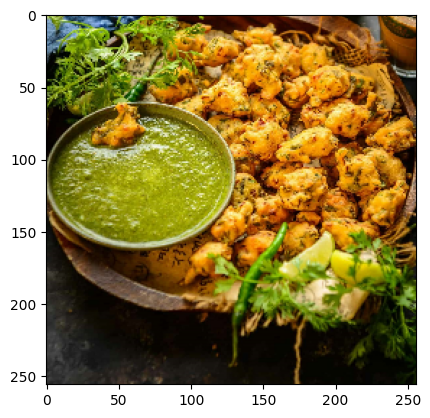

In [39]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [24]:
#saving model

model.save("rawModelv1.h5")